In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [2]:
def SIR(t, y, beta, gamma):
  S = y[0]
  I = y[1]
  R = y[2]
  dSdt = -beta * S * I
  dIdt = beta * S * I - gamma * I
  dRdt = gamma * I
  return np.array([dSdt, dIdt, dRdt])

In [3]:
def maki_thompson(t, y, lambd, alpha):
  X = y[0]
  Y = y[1]
  Z = y[2]
  dX = -lambd * X * Y
  dY =  lambd * X * Y - alpha * Y * (1 - X)
  dZ =  alpha * Y * (1 - X)
  return np.array([dX, dY, dZ])

In [4]:
def rk4(f, y0, t, beta, gamma):
  n = len(t)
  y0 = np.array(y0)
  y = np.zeros((n, len(y0)))
  y[0] = y0

  for i in range(n-1):
    h = t[i+1] - t[i]

    k1 = np.array(f(t[i], y[i], beta, gamma))
    k2 = np.array(f(t[i] + h/2, y[i] + h*k1/2, beta, gamma))
    k3 = np.array(f(t[i] + h/2, y[i] + h*k2/2, beta, gamma))
    k4 = np.array(f(t[i] + h, y[i] + h*k3, beta, gamma))

    y[i+1] = y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

  return y

In [5]:
s_0, i_0, r_0 = 0.45, 0.45, 0.10
y_0 = np.array([s_0, i_0, r_0])
t = np.linspace(0, 40, 2000)

# N Epocas
n_ephocs = 10000


beta = 0.8
gamma = 0.05


# Real RK4 Solution
solSIR = rk4(SIR, y_0, t, beta, gamma);
solMT = rk4(maki_thompson, y_0, t, beta, gamma);

In [6]:
colorREAL = "black"
colorBalanced = "red"
colorUnbalanced = "blue"
colorDATA = "black"

In [7]:
lw_balanced = 3.0
lw_unbalanced = 3.0
lw_real = 3.5

ls_balanced = "--"
ls_unbalanced = "--"
ls_real = "-"

alpha_real = 0.7
alpha_balanced = 1.0
alpha_unbalanced = 1.0

In [8]:
plt.rcParams['font.size'] = 24          # Tamaño base
plt.rcParams['axes.labelsize'] = 20     # Etiquetas de ejes (x, y)
plt.rcParams['xtick.labelsize'] = 18    # Números en eje x
plt.rcParams['ytick.labelsize'] = 18    # Números en eje y
plt.rcParams['legend.fontsize'] = 16    # Leyenda
plt.rcParams['axes.linewidth'] = 1.5    # Grosor del marco

## SIR

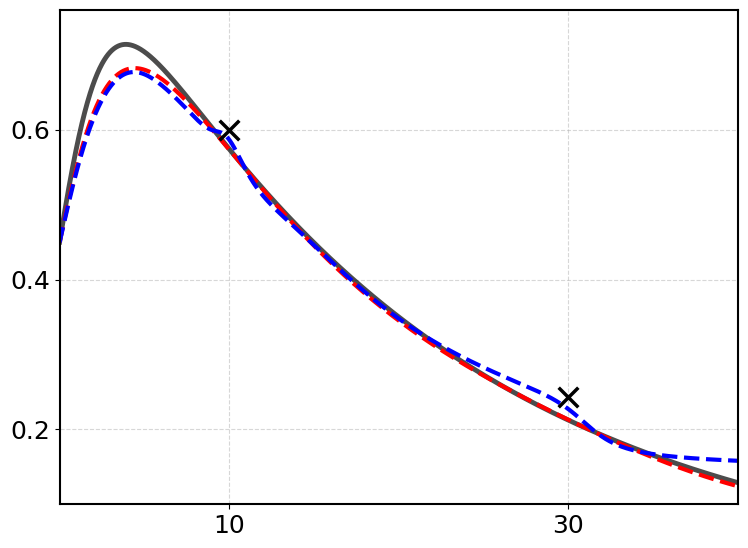

In [9]:
# Cargamos el archivo
data = np.load("sir_results_cache_2.npz")

# Recuperamos las variables
ruido = data['sol_noisy']
y_balanced = data['pred_balanced']
y_unbalanced = data['pred_unbalanced']
H_POINTS_two = data['H_POINTS']

# Ejemplo rápido de gráfica
plt.figure(figsize=(8,6))
plt.plot(t, solSIR[:, 1], color = colorREAL, linestyle = ls_real, linewidth = lw_real, alpha = alpha_real)
plt.plot(t, y_balanced[:, 1], color = colorBalanced, linestyle = ls_balanced, linewidth = lw_balanced, alpha = alpha_balanced)
plt.plot(t, y_unbalanced[:, 1], color = colorUnbalanced, linestyle = ls_unbalanced, linewidth = lw_unbalanced, alpha = alpha_unbalanced)
plt.scatter(t[H_POINTS_two], ruido[H_POINTS_two, 1], color = colorDATA, marker = 'x', s = 200, linewidths = 2.5, zorder = 2)

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.ylim(0.1, 0.76)
plt.margins(0.0)
ax = plt.gca()
ax.set_xticks([10, 30])
#ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

[ 500 1499]


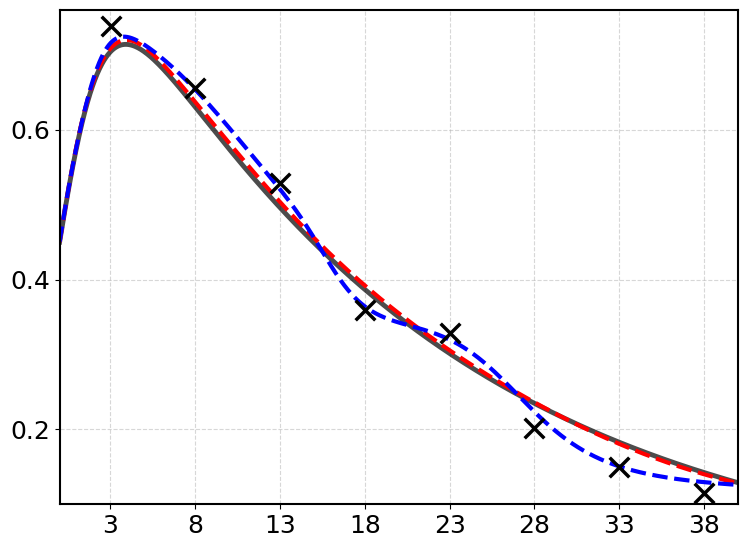

In [10]:
# Cargamos el archivo
data = np.load("sir_results_cache_8.npz")

# Recuperamos las variables
t = np.linspace(0, 40, 2000)
ruido = data['sol_noisy']
y_balanced = data['pred_balanced']
y_unbalanced = data['pred_unbalanced']
H_POINTS_eight = data['H_POINTS']

print(H_POINTS_two)
# Ejemplo rápido de gráfica
plt.figure(figsize=(8,6))
plt.plot(t, solSIR[:, 1], color = colorREAL, linestyle = ls_real, linewidth = lw_real, alpha = alpha_real)
plt.plot(t, y_balanced[:, 1], color = colorBalanced, linestyle = ls_balanced, linewidth = lw_balanced, alpha = alpha_balanced)
plt.plot(t, y_unbalanced[:, 1], color = colorUnbalanced, linestyle = ls_unbalanced, linewidth = lw_unbalanced, alpha = alpha_unbalanced)
plt.scatter(t[H_POINTS_eight], ruido[H_POINTS_eight, 1], color = colorDATA, marker = 'x', s = 200, linewidths = 2.5, zorder = 2)

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.ylim(0.1, 0.76)
plt.margins(0.0)
ax = plt.gca()
ax.set_xticks([3,8, 13, 18, 23, 28, 33, 38])
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

## MT

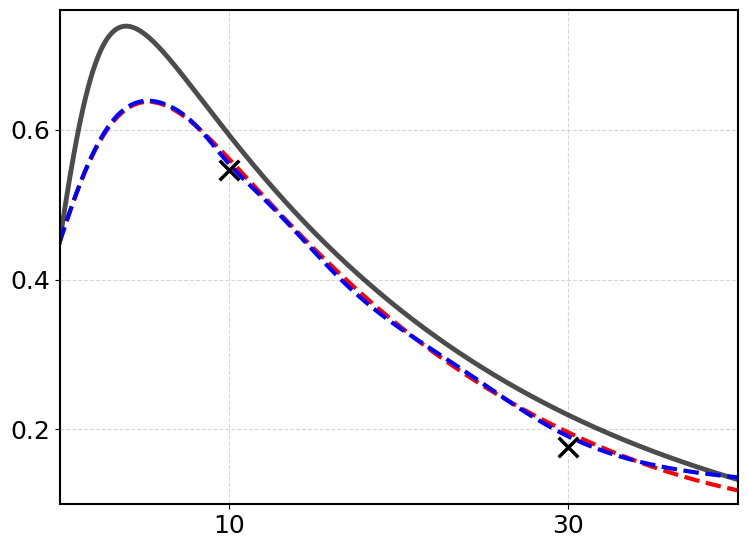

In [11]:
# Cargamos el archivo
data = np.load("MT_results_cache_2.npz")

# Recuperamos las variables
t = np.linspace(0, 40, 2000)
ruido = data['sol_noisy']
y_balanced = data['pred_balanced']
y_unbalanced = data['pred_unbalanced']
H_POINTS_two = data['H_POINTS']

# Ejemplo rápido de gráfica
plt.figure(figsize=(8,6))
plt.plot(t, solMT[:, 1], color = colorREAL, linestyle = ls_real, linewidth = lw_real, alpha = alpha_real)
plt.plot(t, y_balanced[:, 1], color = colorBalanced, linestyle = ls_balanced, linewidth = lw_balanced, alpha = alpha_balanced)
plt.plot(t, y_unbalanced[:, 1], color = colorUnbalanced, linestyle = ls_unbalanced, linewidth = lw_unbalanced, alpha = alpha_unbalanced)

plt.scatter(t[H_POINTS_two], ruido[H_POINTS_two, 1], color = colorDATA, marker = 'x', s = 200, linewidths = 2.5, zorder = 2)

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.ylim(0.1, 0.76)
plt.margins(0.0)
ax = plt.gca()
ax.set_xticks([10, 30])
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

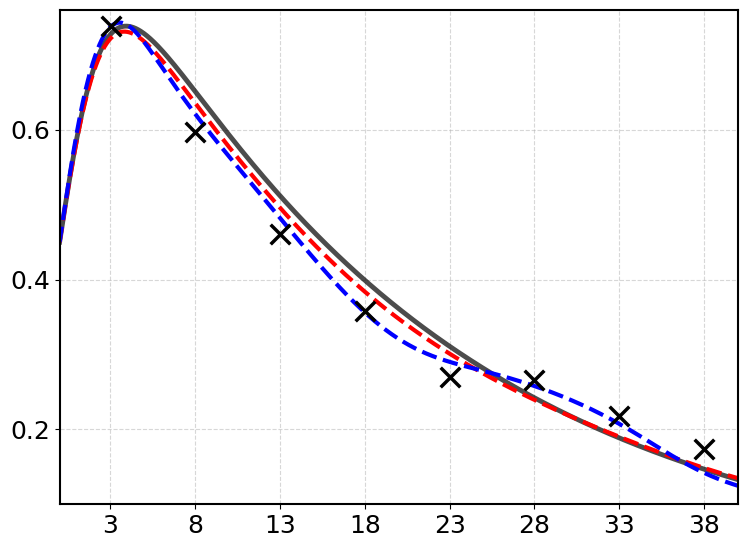

In [12]:
# Cargamos el archivo
data = np.load("MT_results_cache_8.npz")

# Recuperamos las variables
t = np.linspace(0, 40, 2000)
ruido = data['sol_noisy']
y_balanced = data['pred_balanced']
y_unbalanced = data['pred_unbalanced']
H_POINTS_eight = data['H_POINTS']

# Ejemplo rápido de gráfica
plt.figure(figsize=(8,6))
plt.plot(t, solMT[:, 1], color = colorREAL, linestyle = ls_real, linewidth = lw_real, alpha = alpha_real)
plt.plot(t, y_balanced[:, 1], color = colorBalanced, linestyle = ls_balanced, linewidth = lw_balanced, alpha = alpha_balanced)
plt.plot(t, y_unbalanced[:, 1], color = colorUnbalanced, linestyle = ls_unbalanced, linewidth = lw_unbalanced, alpha = alpha_unbalanced)
plt.scatter(t[H_POINTS_eight], ruido[H_POINTS_eight, 1], color = colorDATA, marker = 'x', s = 200, linewidths = 2.5, zorder = 2)

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.ylim(0.1, 0.76)
plt.margins(0.0)
ax = plt.gca()
ax.set_xticks([3,8, 13, 18, 23, 28, 33, 38])
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

# Partial data

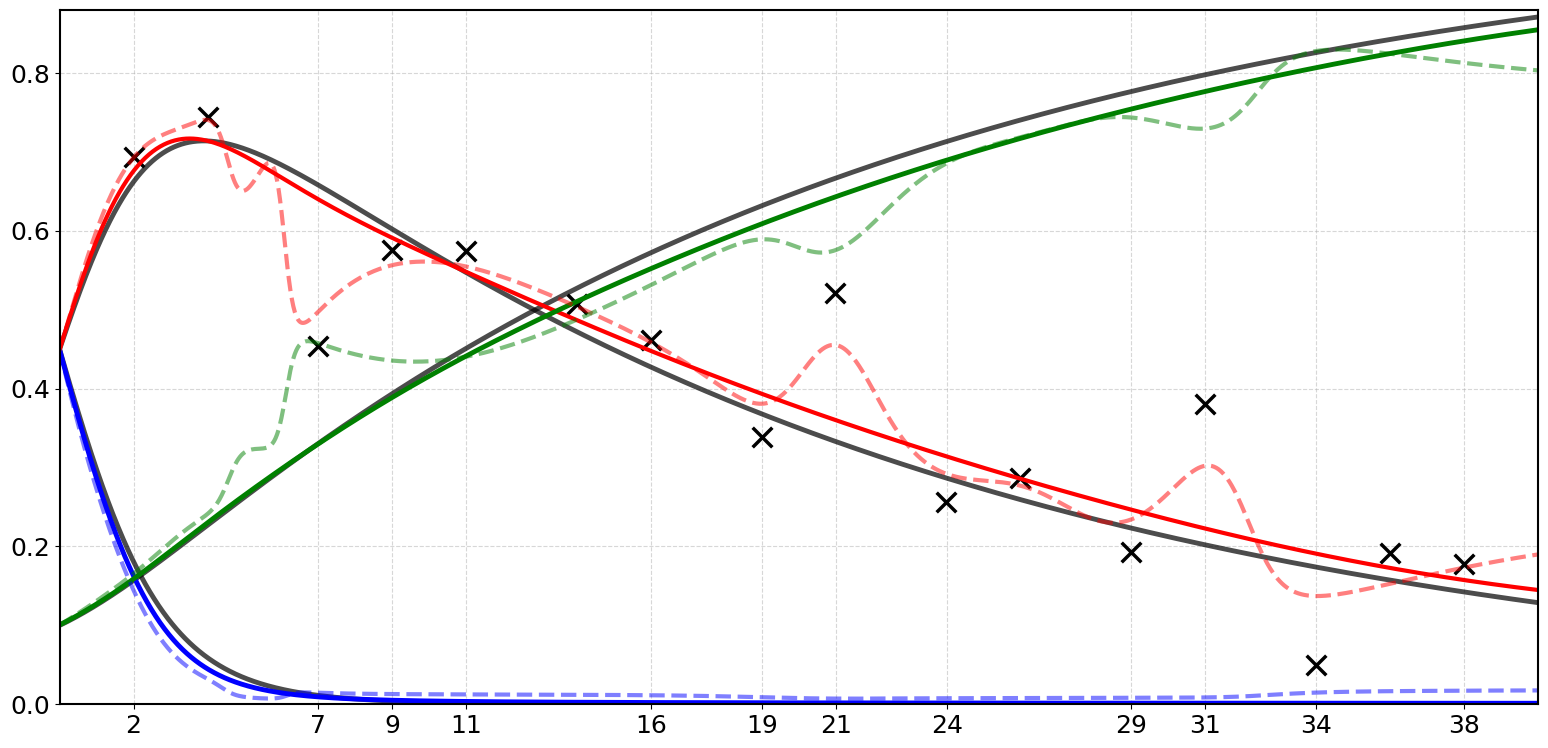

In [28]:
# Cargamos el archivo
data = np.load("SIR_partial.npz")

# Recuperamos las variables
t = np.linspace(0, 40, 2000)
ruido = data['sol_noisy']
y_balanced = data['pred_balanced']
y_unbalanced = data['pred_unbalanced']
H_POINTS_sixteen = data['H_POINTS']


# SIR
plt.figure(figsize=(16,8))
plt.scatter(t[H_POINTS_sixteen], ruido[H_POINTS_sixteen, 1], label = 'Noisy data', color = colorDATA, marker = 'x',  s = 200, linewidths = 2.5, zorder = 2)

plt.plot(t, solSIR[:, 0], color = 'black', linestyle = '-', linewidth = lw_real, alpha = alpha_real, label = 'S/I/R real')
plt.plot(t, solSIR[:, 1], color = 'black', linestyle = '-', linewidth = lw_real, alpha = alpha_real)
plt.plot(t, solSIR[:, 2], color = 'black', linestyle = '-', linewidth = lw_real, alpha = alpha_real)

plt.plot(t, y_balanced[:, 0], color = 'blue', linestyle = '-', linewidth = 3.5, alpha = 1.0, label = 'Approx. S balanced')
plt.plot(t, y_balanced[:, 1], color = colorBalanced, linestyle = '-', linewidth = lw_balanced, alpha = alpha_balanced, label = 'Approx. I balanced')
plt.plot(t, y_balanced[:, 2], color = 'green', linestyle = '-', linewidth = 3.5, alpha = 1.0, label = 'Approx. R balanced')

plt.plot(t, y_unbalanced[:, 0], color = 'blue', linestyle = '--', linewidth = 3.0, alpha = 0.5, label = 'Approx. S unbalanced')
plt.plot(t, y_unbalanced[:, 1], color = colorBalanced, linestyle = ls_unbalanced, linewidth = lw_unbalanced, alpha = 0.5, label = 'Approx. I unbalanced')
plt.plot(t, y_unbalanced[:, 2], color = 'green', linestyle = '--', linewidth = 3.0, alpha = 0.5, label = 'Approx. R unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.margins(0.0)
plt.ylim(0.0, 0.88)
ax = plt.gca()
ax.set_xticks([2, 4, 7, 9, 11, 14, 16, 19, 21, 24, 26, 29, 31, 34, 36, 38])
ax.set_xticks([2, 7, 9, 11, 16, 19, 21, 24, 29, 31, 34, 38])
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

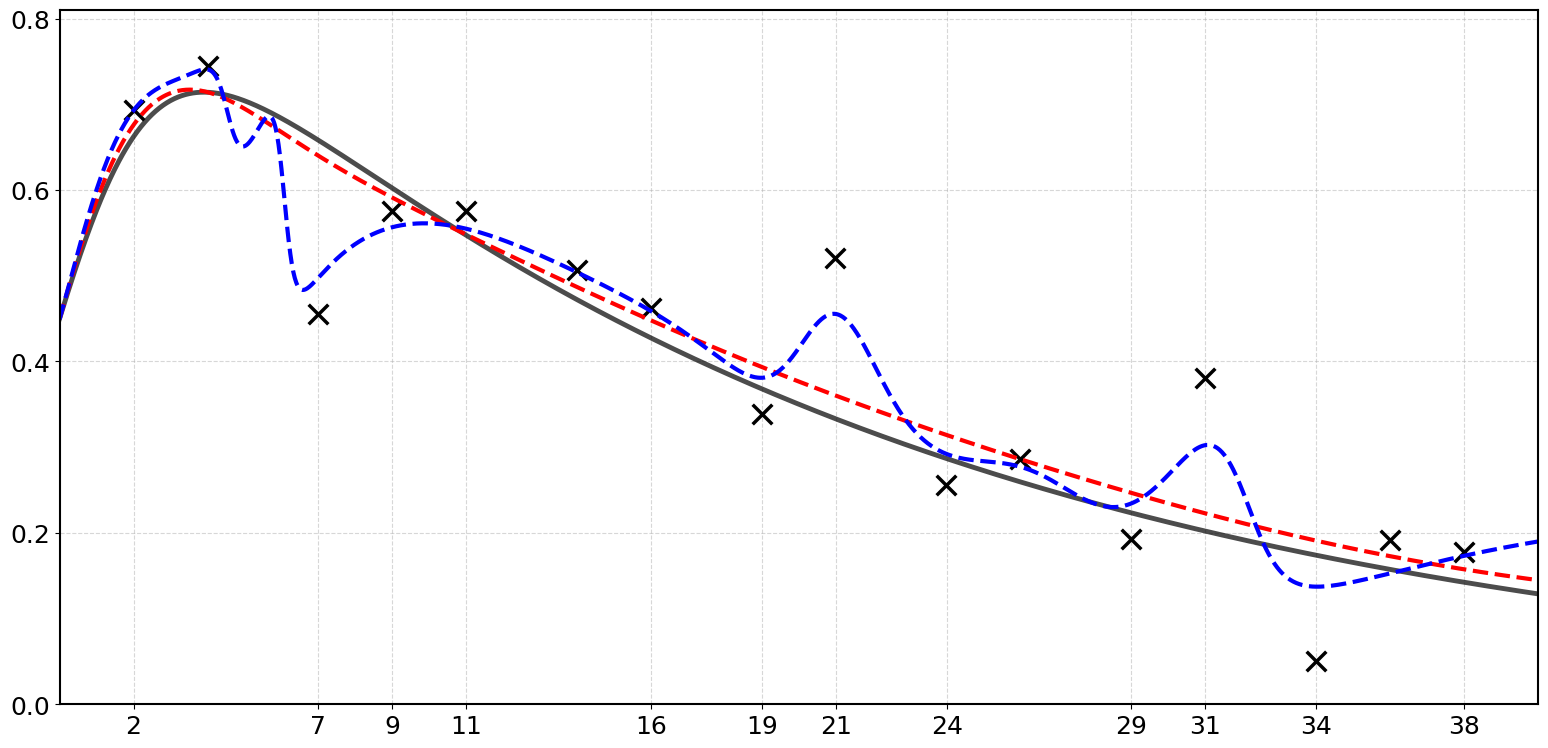

In [19]:
# Cargamos el archivo
data = np.load("SIR_partial.npz")

# Recuperamos las variables
t = np.linspace(0, 40, 2000)
ruido = data['sol_noisy']
y_balanced = data['pred_balanced']
y_unbalanced = data['pred_unbalanced']
H_POINTS_sixteen = data['H_POINTS']


# SIR
plt.figure(figsize=(16,8))
plt.scatter(t[H_POINTS_sixteen], ruido[H_POINTS_sixteen, 1], label = 'Noisy data', color = colorDATA, marker = 'x',  s = 200, linewidths = 2.5, zorder = 2)

#plt.plot(t, solSIR[:, 0], color = 'black', linestyle = '-', linewidth = 3.2, alpha = 0.4, label = 'S/I/R real')
plt.plot(t, solSIR[:, 1], color = colorREAL, linestyle = ls_real, linewidth = lw_real, alpha = alpha_real)
#plt.plot(t, solSIR[:, 2], color = 'black', linestyle = '-', linewidth = 3.2, alpha = 0.4)

#plt.plot(t, y_balanced[:, 0], color = 'blue', linestyle = '-', linewidth = 3.5, alpha = 1.0, label = 'Approx. S balanced')
plt.plot(t, y_balanced[:, 1], color = colorBalanced, linestyle = ls_balanced, linewidth = lw_balanced, alpha = alpha_balanced, label = 'Approx. I balanced')
#plt.plot(t, y_balanced[:, 2], color = 'green', linestyle = '-', linewidth = 3.5, alpha = 1.0, label = 'Approx. R balanced')

#plt.plot(t, y_unbalanced[:, 0], color = 'blue', linestyle = '--', linewidth = 3.0, alpha = 0.5, label = 'Approx. S unbalanced')
plt.plot(t, y_unbalanced[:, 1], color = colorUnbalanced, linestyle = ls_unbalanced, linewidth = lw_unbalanced, alpha = alpha_unbalanced, label = 'Approx. I unbalanced')
#plt.plot(t, y_unbalanced[:, 2], color = 'green', linestyle = '--', linewidth = 3.0, alpha = 0.5, label = 'Approx. R unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.margins(0.0)
plt.ylim(0.0, 0.81)
ax = plt.gca()
ax.set_xticks([2, 4, 7, 9, 11, 14, 16, 19, 21, 24, 26, 29, 31, 34, 36, 38])
ax.set_xticks([2, 7, 9, 11, 16, 19, 21, 24, 29, 31, 34, 38])
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

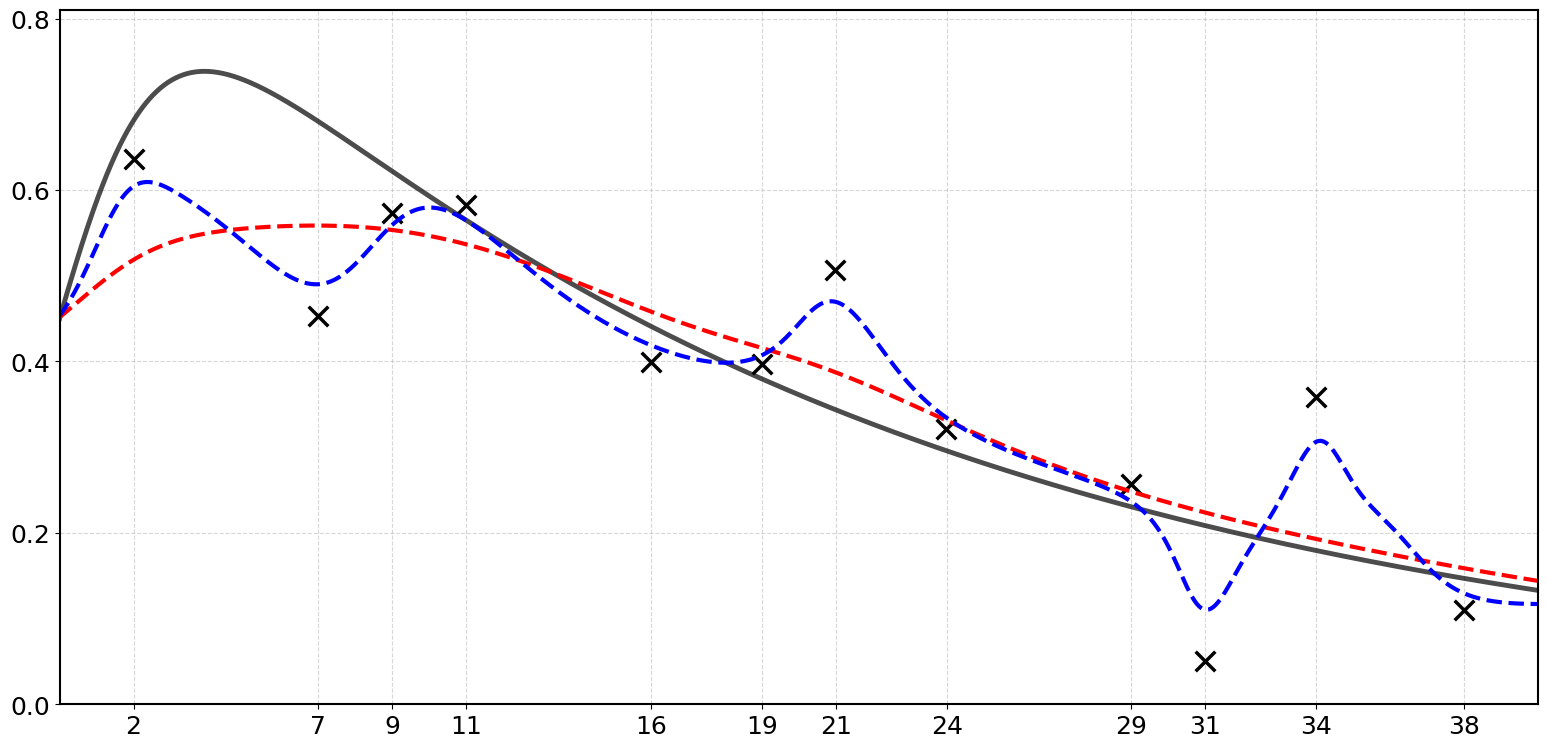

In [14]:
## Cargamos el archivo
data = np.load("MT_partial_12.npz")

# Recuperamos las variables
t = np.linspace(0, 40, 2000)
ruido = data['sol_noisy']
y_balanced = data['pred_balanced']
y_unbalanced = data['pred_unbalanced']
H_POINTS_sixteen = data['H_POINTS']


plt.figure(figsize=(16, 8))

# MT
plt.scatter(t[H_POINTS_sixteen], ruido[H_POINTS_sixteen, 1], label = 'Noisy data', color = colorDATA, marker = 'x', s = 200, linewidths = 2.5, zorder = 2)

#plt.plot(t, solMT[:, 0], color = 'black', linestyle = '-', linewidth = 3.2, alpha = 0.4, label = 'X/Y/Z real')
plt.plot(t, solMT[:, 1], color = colorREAL, linestyle = ls_real, linewidth = lw_real, alpha = alpha_real)
#plt.plot(t, solMT[:, 2], color = 'black', linestyle = '-', linewidth = 3.2, alpha = 0.4)

#plt.plot(t, y_balanced[:, 0], color = 'blue', linestyle = '-', linewidth = 3.5, alpha = 1.0, label = 'Approx. X balanced')
plt.plot(t, y_balanced[:, 1], color = colorBalanced, linestyle = ls_balanced, linewidth = lw_balanced, alpha = alpha_balanced, label = 'Approx. Y balanced')
#plt.plot(t, y_balanced[:, 2], color = 'green', linestyle = '-', linewidth = 3.5, alpha = 1.0, label = 'Approx. Z balanced')

#plt.plot(t, y_unbalanced[:, 0], color = 'blue', linestyle = '--', linewidth = 3.0, alpha = 0.5, label = 'Approx. X unbalanced')
plt.plot(t, y_unbalanced[:, 1], color = colorUnbalanced, linestyle = ls_unbalanced, linewidth = lw_unbalanced, alpha = alpha_unbalanced, label = 'Approx. Y unbalanced')
#plt.plot(t, y_unbalanced[:, 2], color = 'green', linestyle = '--', linewidth = 3.0, alpha = 0.5, label = 'Approx. Z unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.ylim(0.0, 0.81)
plt.margins(0.0)
ax = plt.gca()
#ax.set_xticks([2, 4, 7, 9, 11, 14, 16, 19, 21, 24, 26, 29, 31, 34, 36, 38])
ax.set_xticks([2, 7, 9, 11, 16, 19, 21, 24, 29, 31, 34, 38])
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()